In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
df = pd.read_csv(
    "Ask A Manager Salary Survey 2024 (Responses) (1).csv",
    encoding="latin1"
)

df.head()

,Timestamp,How old are you?,What industry is your employer in?,What is the functional area of your job (this might be different from your company's industry)?,Job title,"If your job title needs additional context, please clarify here:","What is your annual salary? This should be your GROSS (pre-tax) income. (You'll indicate the currency in a later question.) If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.","How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Only include monetary compensation here, not the value of benefits, tuition reimbursement, etc. If your bonus or overtime varies from year to year, use the most recent figures.",Please indicate the currency,"If ""Other,"" please indicate the currency here:",...,How many years of professional work experience do you have in your field?,What is your highest level of education completed?,What is your gender?,What is your race? (Choose all that apply.),Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26
0,4-9-2024 11:01:42,25-34,Media & Digital,Media & Digital,Digital Project Manager,NaN,73000,NaN,USD,NaN,...,5-7 years,College degree,Woman,White,NaN,NaN,NaN,NaN,NaN,NaN
1,4-9-2024 11:02:14,35-44,Education (Higher Education),Health care,Senior Director,NaN,150000,4500.0,USD,NaN,...,11-20 years,College degree,Woman,White,NaN,NaN,NaN,NaN,NaN,NaN
2,4-9-2024 11:02:18,35-44,Nonprofits,Administration,Advancement Operations Manager,NaN,53800,NaN,USD,NaN,...,8-10 years,Master's degree,Woman,White,NaN,NaN,NaN,NaN,NaN,NaN
3,4-9-2024 11:02:19,25-34,Government & Public Administration,Government & Public Administration,Program Analyst,NaN,97000,0.0,USD,NaN,...,8-10 years,Master's degree,Woman,White,NaN,NaN,NaN,NaN,NaN,NaN
4,4-9-2024 11:02:24,25-34,Government & Public Administration,Administration,Project Coordinator,NaN,64000,NaN,USD,NaN,...,2-4 years,College degree,Woman,White,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
salary_col = [c for c in df.columns if "annual salary" in c.lower()][0]

rename_map = {
    "How old are you?": "age",
    "What industry is your employer in?": "industry",
    "Job title": "job_title",
    "How many years of professional work experience do you have overall?": "exp_overall",
    "How many years of professional work experience do you have in your field?": "exp_field",
    "What is your highest level of education completed?": "education",
    "What is your gender?": "gender",
    "What country do you work in? (Countries listed had by far the largest representation last year. Please write in your country if it's not listed.)": "country",
    salary_col: "salary"
}

df = df.rename(columns=rename_map)

df.columns

Index(['Timestamp', 'age', 'industry',
       'What is the functional area of your job (this might be different from your company's industry)?',
       'job_title',
       'If your job title needs additional context, please clarify here:',
       'salary',
       'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Only include monetary compensation here, not the value of benefits, tuition reimbursement, etc. If your bonus or overtime varies from year to year, use the most recent figures.',
       'Please indicate the currency',
       'If "Other," please indicate the currency here: ',
       'If your income needs additional context, please provide it here:',
       'country', 'If you're in the U.S., what state do you work in?',
       'What city/region do you work in?', 'Are you remote or on-site?',
       'Is your job unionized?', 'exp_overall', 'exp_field', 'education',
       'gender', 'What is your race? (Choose all t

In [7]:
df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
df = df.dropna(subset=["salary"])

bins = [0, 40000, 80000, np.inf]
labels = ["Low", "Mid", "High"]

df["salary_class"] = pd.cut(df["salary"], bins=bins, labels=labels)

df["salary_class"].value_counts()

,count
salary_class,
High,7713
Mid,4915
Low,778


In [8]:
cols = [
    "age",
    "industry",
    "job_title",
    "exp_overall",
    "exp_field",
    "education",
    "gender",
    "country",
    "salary",
    "salary_class"
]

data = df[cols].dropna(subset=["salary_class"])
data.head()

,age,industry,job_title,exp_overall,exp_field,education,gender,country,salary,salary_class
0,25-34,Media & Digital,Digital Project Manager,5-7 years,5-7 years,College degree,Woman,United States,73000,Mid
1,35-44,Education (Higher Education),Senior Director,11-20 years,11-20 years,College degree,Woman,United States,150000,High
2,35-44,Nonprofits,Advancement Operations Manager,11-20 years,8-10 years,Master's degree,Woman,United States,53800,Mid
3,25-34,Government & Public Administration,Program Analyst,8-10 years,8-10 years,Master's degree,Woman,United States,97000,High
4,25-34,Government & Public Administration,Project Coordinator,8-10 years,2-4 years,College degree,Woman,United States,64000,Mid


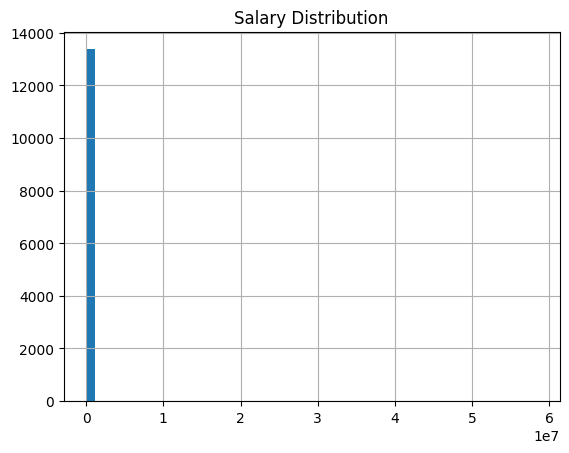

In [9]:
plt.figure()
data["salary"].hist(bins=50)
plt.title("Salary Distribution")
plt.show()

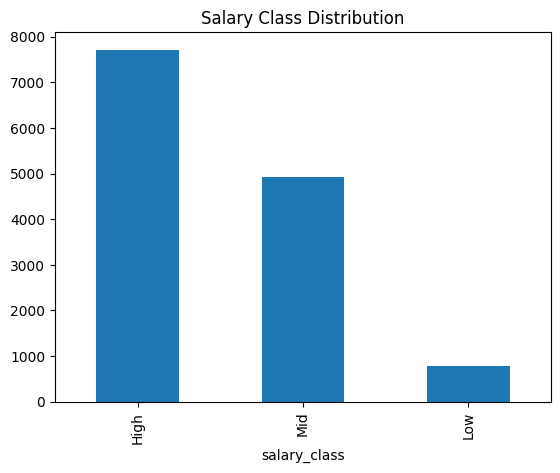

In [10]:
data["salary_class"].value_counts().plot(kind="bar")
plt.title("Salary Class Distribution")
plt.show()

In [11]:
top_titles = data["job_title"].value_counts().nlargest(100).index
data["job_title"] = data["job_title"].where(data["job_title"].isin(top_titles), "Other")

In [12]:
X = data.drop(columns=["salary_class", "salary"])
y = data["salary_class"]

In [13]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocess = ColumnTransformer([
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),

    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), num_cols)
])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150),
    "Gradient Boosting": GradientBoostingClassifier()
}


 Logistic Regression
              precision    recall  f1-score   support

        High       0.76      0.85      0.80      1557
         Low       0.64      0.18      0.28       164
         Mid       0.62      0.58      0.60       961

    accuracy                           0.71      2682
   macro avg       0.68      0.54      0.56      2682
weighted avg       0.70      0.71      0.70      2682



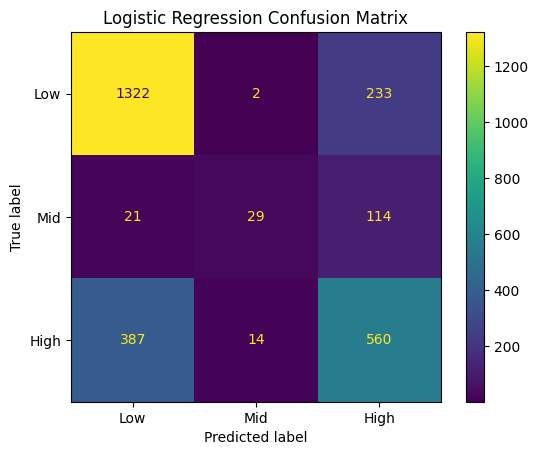


 Random Forest
              precision    recall  f1-score   support

        High       0.74      0.81      0.77      1557
         Low       0.49      0.17      0.25       164
         Mid       0.57      0.54      0.56       961

    accuracy                           0.67      2682
   macro avg       0.60      0.51      0.53      2682
weighted avg       0.66      0.67      0.66      2682



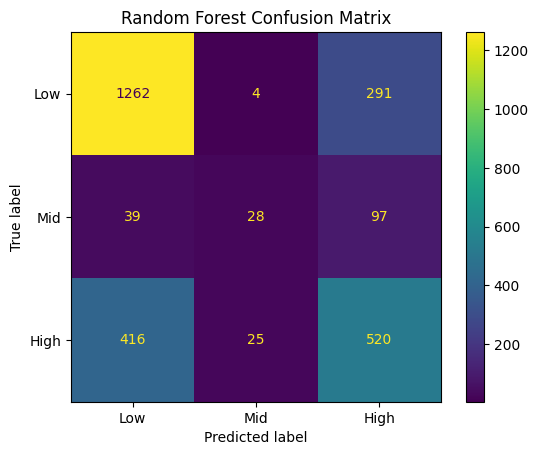


 Gradient Boosting
              precision    recall  f1-score   support

        High       0.73      0.88      0.80      1557
         Low       0.60      0.15      0.24       164
         Mid       0.62      0.50      0.55       961

    accuracy                           0.70      2682
   macro avg       0.65      0.51      0.53      2682
weighted avg       0.68      0.70      0.68      2682



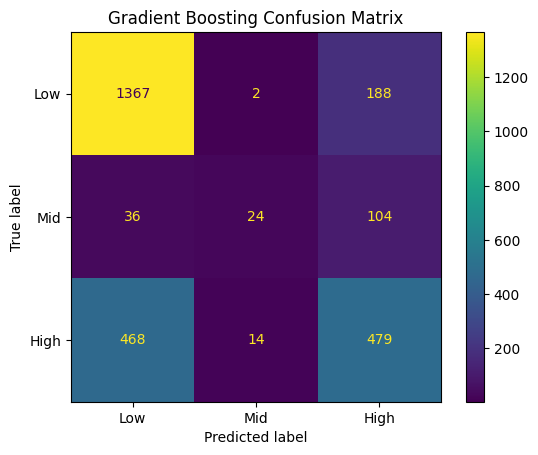

In [21]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    print("\n", name)
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Low","Mid","High"]).plot()
    plt.title(name + " Confusion Matrix")
    plt.savefig(f"{name}_confusion_matrix.png", bbox_inches="tight")
    plt.show()

    results[name] = pipe

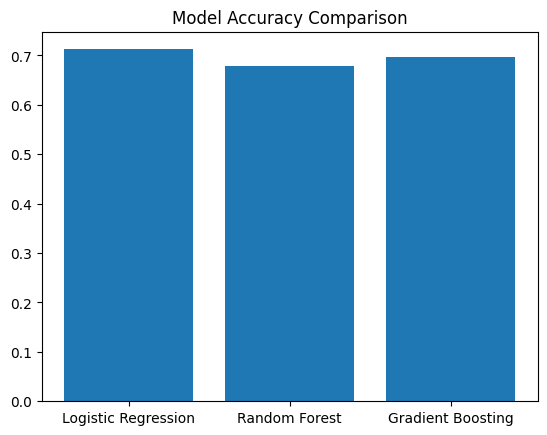

In [20]:
accuracies = []

for name, pipe in results.items():
    preds = pipe.predict(X_test)
    acc = (preds == y_test).mean()
    accuracies.append(acc)

plt.figure()
plt.bar(results.keys(), accuracies)
plt.title("Model Accuracy Comparison")
plt.savefig("model_accuracy_comparison.png", bbox_inches="tight")
plt.show()

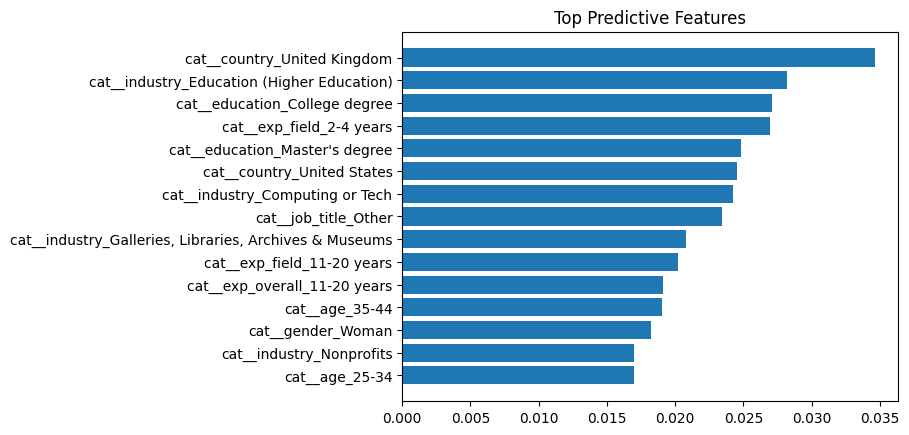

In [22]:
rf = results["Random Forest"]

feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_

idx = np.argsort(importances)[-15:]

plt.figure()
plt.barh(range(len(idx)), importances[idx])
plt.yticks(range(len(idx)), feature_names[idx])
plt.title("Top Predictive Features")
plt.savefig("feature_importance.png", bbox_inches="tight")
plt.show()

In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_r, preds_r)
mae = mean_absolute_error(y_test_r, preds_r)

mse = mean_squared_error(y_test_r, preds_r)
rmse = np.sqrt(mse)

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.4541087656933206
MAE: 40929.74591773865
RMSE: 212444.51701298615
